In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
from itertools import combinations

In [98]:
variance_opt_data = pd.read_csv(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_-3.txt_var_opt_data.txt",
delimiter=" ")

commutator_opt_data = pd.read_csv(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_-3.txt_comm_opt_data.txt",
delimiter=" ")

In [99]:
commutator_opt_data

E_FCI,V_0,V_optimized,Sum_CommSq_0,Sum_CommSq_Optimized,a_opt,b_opt,c_opt
-1.871168 0.125538 0.166223 0.219581 0.001124 1.0 1.000086                                          -1.992064                        
          0.125206 0.166223 0.219016 0.001124 1.0 0.999996                                          -1.991964                        
          0.125587 0.166224 0.220203 0.001124 1.0 1.000056                                          -1.992049                        
          0.125533 0.166223 0.219768 0.001124 1.0 1.000061                                          -1.992036                        
          0.125508 0.166224 0.219626 0.001124 1.0 0.999685                                          -1.991667                        
          0.125291 0.166223 0.219000 0.001124 1.0 0.999898                                          -1.991871                        
          0.125311 0.166224 0.219172 0.001124 1.0 0.999782                                          -1.991763                        
          0.125332 0.166224 0.219544 0.001124 1.0 0.999740                                          -1.991721                        
          0.125243 0.166223 0.219455 0.001124 1.0 1.000202                                          -1.992177                        
          0.125251 0.166223 0.219731 0.001124 1.0 0.999716                                          -1.991694

In [96]:
optimized_value_indices = ["V_optimized", "Sum_CommSq_Optimized", "b_opt", "c_opt"]

In [97]:
np.all(np.isclose(commutator_opt_data[optimized_value_indices].iloc[0], 
           commutator_opt_data[optimized_value_indices].iloc[2], atol=1e-3))

KeyError: "None of [Index(['V_optimized', 'Sum_CommSq_Optimized', 'b_opt', 'c_opt'], dtype='object')] are in the [columns]"

In [62]:
def same_minimum(i, j, df, tol=1e-3) -> bool: 
    return np.all(np.isclose(df[optimized_value_indices].iloc[i], 
           df[optimized_value_indices].iloc[j], atol=tol))

In [63]:
same_minimum(0, 2, variance_opt_data)

False

In [64]:
variance_opt_data.shape[0]

30

In [83]:
variance_graph = nx.Graph()
variance_graph.add_nodes_from(range(variance_opt_data.shape[0]))
for i, j in combinations(g.nodes, 2):
    if same_minimum(i, j, variance_opt_data, tol=1e-3):
        variance_graph.add_edge(i, j)

distinct_var_minima = [min(comp) for comp in nx.connected_components(variance_graph)]
var_minima_hit_counts = [len(comp) for comp in nx.connected_components(variance_graph)]

variance_minima = variance_opt_data[optimized_value_indices].iloc[distinct_var_minima]
variance_minima["hits"] = var_minima_hit_counts
variance_minima

,V_optimized,Sum_CommSq_Optimized,b_opt,c_opt,hits
0,0.033754,0.005976,0.999997,-1.918154,14
2,0.040187,0.002293,1.000043,-1.950023,13
6,0.025049,0.008689,1.000001,-1.436984,3


In [93]:
w = np.where(commutator_opt_data["V_0"] < commutator_opt_data["V_optimized"])[0]

commutator_opt_data.iloc[w]

,E_FCI,V_0,V_optimized,Sum_CommSq_0,Sum_CommSq_Optimized,a_opt,b_opt,c_opt
5,-1.891695,0.489070,1.909580,0.195701,0.003807,1.0,-0.999525,-0.000475
12,-1.891695,0.934440,1.909557,0.387491,0.003807,1.0,-1.000007,0.000185
19,-1.891695,1.486477,1.909548,0.481840,0.003807,1.0,-1.000001,-0.000160
20,-1.891695,1.085262,1.909550,0.387846,0.003807,1.0,-1.000139,-0.000058
27,-1.891695,0.605962,1.909547,0.232649,0.003807,1.0,-1.000658,0.000368


In [88]:
variance_opt_data["Sum_CommSq_0"] > variance_opt_data["Sum_CommSq_Optimized"]

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9     True
10    True
11    True
12    True
13    True
14    True
15    True
16    True
17    True
18    True
19    True
20    True
21    True
22    True
23    True
24    True
25    True
26    True
27    True
28    True
29    True
dtype: bool

In [87]:
variance_opt_data.iloc[]

NotImplementedError: iLocation based boolean indexing on an integer type is not available

In [85]:
print(variance_minima)

   V_optimized  Sum_CommSq_Optimized     b_opt     c_opt  hits
0     0.033754              0.005976  0.999997 -1.918154    14
2     0.040187              0.002293  1.000043 -1.950023    13
6     0.025049              0.008689  1.000001 -1.436984     3


In [82]:
comm_graph = nx.Graph()
comm_graph.add_nodes_from(range(commutator_opt_data.shape[0]))
for i, j in combinations(g.nodes, 2):
    if same_minimum(i, j, commutator_opt_data, tol=1e-3):
        comm_graph.add_edge(i, j)

comm_var_minima = [min(comp) for comp in nx.connected_components(comm_graph)]
comm_minima_hit_counts = [len(comp) for comp in nx.connected_components(comm_graph)]

comm_minima = commutator_opt_data[optimized_value_indices].iloc[comm_var_minima]
comm_minima["hits"] = comm_minima_hit_counts
comm_minima

,V_optimized,Sum_CommSq_Optimized,b_opt,c_opt,hits
0,0.034534,0.005517,0.999893,-1.954756,12
1,0.041587,0.001439,0.999999,-1.991588,7
5,1.909580,0.003807,-0.999525,-0.000475,5
6,0.041913,0.009481,1.000110,-1.651565,1
11,0.091966,0.006623,1.000014,-1.902200,3
13,0.097948,0.009129,1.000081,-1.920187,1
25,0.164433,0.006194,0.999969,-1.959137,1


In [84]:
print(comm_minima)

    V_optimized  Sum_CommSq_Optimized     b_opt     c_opt  hits
0      0.034534              0.005517  0.999893 -1.954756    12
1      0.041587              0.001439  0.999999 -1.991588     7
5      1.909580              0.003807 -0.999525 -0.000475     5
6      0.041913              0.009481  1.000110 -1.651565     1
11     0.091966              0.006623  1.000014 -1.902200     3
13     0.097948              0.009129  1.000081 -1.920187     1
25     0.164433              0.006194  0.999969 -1.959137     1


In [67]:
distinct_var_minima

[0, 2, 6]

In [68]:
var_minima_hit_counts

[14, 13, 3]

In [17]:
np.isclose(commutator_opt_data.iloc[0], commutator_opt_data.iloc[2], atol=1e-3)

array([ True, False,  True, False,  True,  True,  True,  True])

In [15]:
commutator_opt_data

,E_FCI,V_0,V_optimized,Sum_CommSq_0,Sum_CommSq_Optimized,a_opt,b_opt,c_opt
0,-1.891695,0.722617,0.034534,0.269427,0.005517,1.0,0.999893,-1.954756
1,-1.891695,0.720866,0.041587,0.207926,0.001439,1.0,0.999999,-1.991588
2,-1.891695,0.475248,0.034534,0.039517,0.005517,1.0,0.999555,-1.954419
3,-1.891695,0.798208,0.034533,0.334229,0.005517,1.0,1.000174,-1.954992
4,-1.891695,0.958639,0.034534,0.353026,0.005517,1.0,1.000160,-1.955058
5,-1.891695,0.489070,1.909580,0.195701,0.003807,1.0,-0.999525,-0.000475
6,-1.891695,0.432980,0.041913,0.138898,0.009481,1.0,1.000110,-1.651565
7,-1.891695,0.290051,0.034535,0.113851,0.005517,1.0,1.000766,-1.955631
8,-1.891695,1.502544,0.041587,0.518006,0.001439,1.0,1.000107,-1.991711
9,-1.891695,0.356652,0.041587,0.130145,0.001439,1.0,1.000027,-1.991621


In [5]:
condition = (variance_opt_data["c_opt"] > -1.9) | (commutator_opt_data["c_opt"] > -1.9)

In [6]:
variance_opt_data[condition]

,E_FCI,V_0,V_optimized,Sum_CommSq_0,Sum_CommSq_Optimized,a_opt,b_opt,c_opt
5,-1.891695,0.489070,0.033754,0.195701,0.005976,1.0,1.000004,-1.918147
6,-1.891695,0.432980,0.025049,0.138898,0.008689,1.0,1.000001,-1.436984
12,-1.891695,0.934440,0.033754,0.387491,0.005976,1.0,0.999992,-1.918156
19,-1.891695,1.486477,0.025049,0.481840,0.008689,1.0,1.000000,-1.437061
20,-1.891695,1.085262,0.025049,0.387846,0.008689,1.0,0.999999,-1.437008
27,-1.891695,0.605962,0.033754,0.232649,0.005976,1.0,0.999998,-1.918165


In [7]:
commutator_opt_data[condition]

,E_FCI,V_0,V_optimized,Sum_CommSq_0,Sum_CommSq_Optimized,a_opt,b_opt,c_opt
5,-1.891695,0.489070,1.909580,0.195701,0.003807,1.0,-0.999525,-0.000475
6,-1.891695,0.432980,0.041913,0.138898,0.009481,1.0,1.000110,-1.651565
12,-1.891695,0.934440,1.909557,0.387491,0.003807,1.0,-1.000007,0.000185
19,-1.891695,1.486477,1.909548,0.481840,0.003807,1.0,-1.000001,-0.000160
20,-1.891695,1.085262,1.909550,0.387846,0.003807,1.0,-1.000139,-0.000058
27,-1.891695,0.605962,1.909547,0.232649,0.003807,1.0,-1.000658,0.000368


In [36]:
np.argmin(commutator_opt_data["Sum_CommSq_Optimized"])

1

In [37]:
commutator_opt_data.iloc[np.argmin(commutator_opt_data["Sum_CommSq_Optimized"])]

E_FCI                  -1.891695
V_0                     0.720866
V_optimized             0.041587
Sum_CommSq_0            0.207926
Sum_CommSq_Optimized    0.001439
a_opt                   1.000000
b_opt                   0.999999
c_opt                  -1.991588
Name: 1, dtype: float64

In [38]:
variance_opt_data.iloc[np.argmin(commutator_opt_data["Sum_CommSq_Optimized"])]

E_FCI                  -1.891695
V_0                     0.720866
V_optimized             0.033754
Sum_CommSq_0            0.207926
Sum_CommSq_Optimized    0.005976
a_opt                   1.000000
b_opt                   0.999998
c_opt                  -1.918143
Name: 1, dtype: float64

In [39]:
commutator_opt_data.iloc[np.argmin(variance_opt_data["V_optimized"])]

E_FCI                  -1.891695
V_0                     1.486477
V_optimized             1.909548
Sum_CommSq_0            0.481840
Sum_CommSq_Optimized    0.003807
a_opt                   1.000000
b_opt                  -1.000001
c_opt                  -0.000160
Name: 19, dtype: float64

In [40]:
variance_opt_data.iloc[np.argmin(variance_opt_data["V_optimized"])]

E_FCI                  -1.891695
V_0                     1.486477
V_optimized             0.025049
Sum_CommSq_0            0.481840
Sum_CommSq_Optimized    0.008689
a_opt                   1.000000
b_opt                   1.000000
c_opt                  -1.437061
Name: 19, dtype: float64

Text(0, 0.5, 'c (optimized by commutator)')

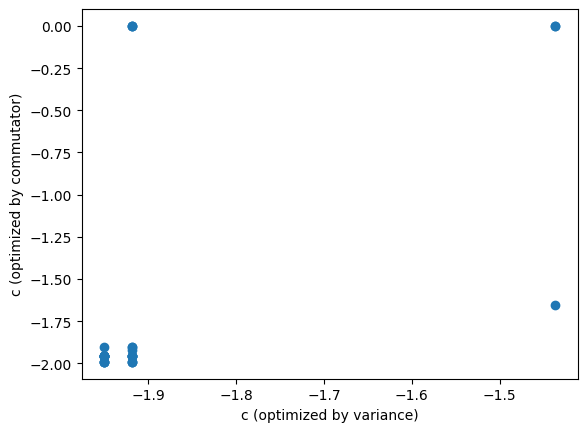

In [17]:
plt.plot(variance_opt_data["c_opt"], commutator_opt_data["c_opt"], "o")
plt.xlabel("c (optimized by variance)")
plt.ylabel("c (optimized by commutator)")

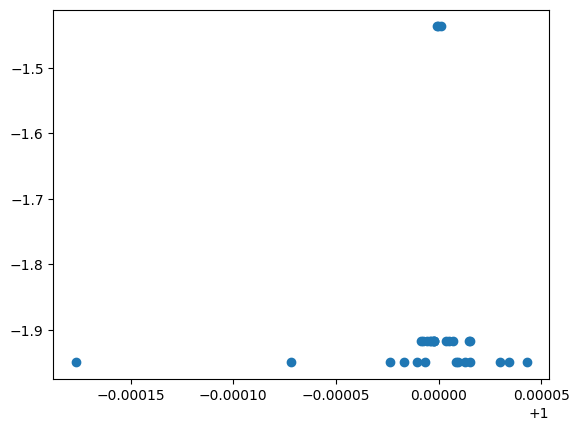

In [14]:
plt.plot(variance_opt_data["b_opt"], variance_opt_data["c_opt"], "o")

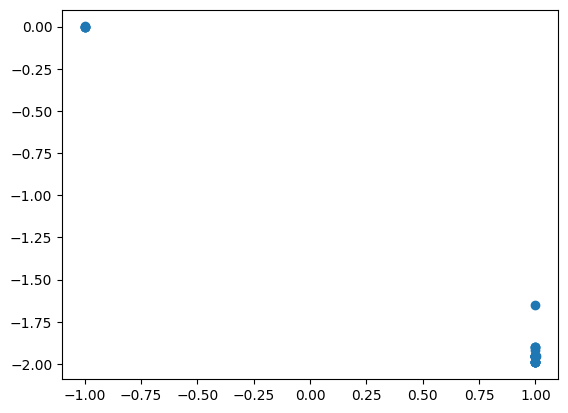

In [15]:
plt.plot(commutator_opt_data["b_opt"], commutator_opt_data["c_opt"], "o")

In [12]:
variance_opt_x = np.loadtxt(
    "../outputs/H4_linear_d2.0670_x0_h4_linear_2.067_perturb_all_0.txt_x_var_opt.txt")
commutator_opt_x = np.loadtxt(
    "../outputs/H4_linear_d2.0670_x0_h4_linear_2.067_perturb_all_0.txt_x_comm_opt.txt")

In [13]:
dxs = variance_opt_x - commutator_opt_x
np.linalg.norm(dxs, axis=1)

array([ 0.09034191,  3.49496126,  0.8559135 ,  3.67181929,  1.55676411,
        3.0689578 ,  1.27816071,  0.0904048 ,  1.57373188,  0.09874772,
        0.82902884,  2.39403475,  2.6474509 ,  2.45954751,  2.26472827,
       19.56644292,  2.75797032,  2.34132051,  0.84250856,  1.76296124,
        1.76149622,  4.07685835,  2.67999117,  2.69190748,  0.09964093,
        1.46783463,  1.74759381,  4.07958079,  1.88103123,  0.09606847])